In [1]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

/u/sebono/miniconda3/envs/.conv_dom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [108]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"

model_id = "gpt2"
device='cuda:1'
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'
if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence =" "

In [112]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [113]:
from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import swap_speaker_tokens_with_metadata, get_shuffled_dialog_data, reorder_tokens

In [114]:
import numpy as np
import re
import pandas as pd

In [115]:
tri_pilot_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/triadic-pilot/conversations.csv")
tri_pilot_df

,file_name,file_content
0,p08_s03,<SPK1> Oh. Yay. It's story time. <SPK2> Hello....
1,p10_s02,<SPK3> Hello. <SPK2> Hi. <SPK0> Hi. <SPK3> You...
2,p09_s04,<SPK2> I will now turn on a start audio video ...
3,p09_s05,"<SPK0> Uh, and how did they turned on? <SPK3> ..."
4,p12_s02,<SPK2> Hello. <SPK1> Hello. <SPK0> Hello. <SPK...
...,...,...
67,p03_s05,<SPK2> [Foreign Language 00:00:57] <SPK1> [For...
68,p11_s05,<SPK0> (laughs) So funny. <SPK2> Hello. <SPK1>...
69,p12_s00,"<SPK2> Hello. <SPK1> Hi. Hi, Jibo. <SPK0> Hi, ..."
70,p10_s00,<SPK2> Hello. I am now on story time mode. My ...


In [116]:
#file_name = tri_pilot_df['file_name'].iloc[0]
#el = tri_pilot_df[tri_pilot_df['file_name']==file_name]['file_content'][0]

In [125]:
file_name = "p07_s03"
dialog = tri_pilot_df[tri_pilot_df['file_name'] == file_name]['file_content'][48]

In [38]:
#file_name = tri_pilot_df['file_name'].iloc[0]
#dialog = tri_pilot_df[tri_pilot_df['file_name']==file_name]['file_content'][0]
#file_name_sample = f'/u/sebono/conversational_dominance/information_exchange_labelling/{file_name}_triadic_ppl.csv'
#all_data = pd.read_csv(file_name_sample)
#all_data.head()

In [118]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{start_of_sentence}{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape

Token indices sequence length is longer than the specified maximum sequence length for this model (7430 > 1024). Running this sequence through the model will result in indexing errors


In [119]:
assert len(matches) == len(dialog_lines)

In [120]:
p1_triadic = compute_p1(encodings, token_list, tokenizer, model, device, max_length = 500, start_of_sentence=start_of_sentence, pattern=pattern, debug=False)

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████           | 7429/7929 [05:46<00:23, 21.46it/s]


In [121]:
p2_triadic = compute_p2(encodings, token_list, tokenizer, model, device, max_length = 500, start_of_sentence=start_of_sentence, pattern=pattern, debug=False)

 99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋  | 7429/7529 [02:34<00:02, 48.22it/s]


In [122]:
p3_triadic = compute_p3(encodings, token_list, tokenizer, model, device,  max_length = 500, start_of_sentence=start_of_sentence, pattern=pattern, debug=False)

/u/sebono/conversational_dominance/information_exchange_labelling/perplexity_labelling.py:129: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████           | 7429/7929 [05:53<00:23, 21.00it/s]


In [127]:
len(p1_triadic)

7430

In [123]:
from utils import correlation_heatmap

In [141]:
all_data = pd.DataFrame({})

In [142]:
model_name="gpt2"
all_data[f"p1"] = p1_triadic
all_data[f"p2"] = p2_triadic
all_data[f"p3"] = p3_triadic

In [128]:
all_data = pd.DataFrame({})
model_name = "llama"
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/triadic-pilot_{p_name}/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}_{model_name}"] = pickle.load(f)[file_name]

In [169]:
file_name_sample = f'/u/sebono/conversational_dominance/information_exchange_labelling/{file_name}_triadic_ppl.csv'
all_data.to_csv(file_name_sample, index=False)

In [43]:
"/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/triadic-pilot_p1/dominance_scores_p07_s03.pkl"

'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/triadic-pilot_p1/dominance_scores_p07_s03.pkl'

In [136]:
from utils import correlation_heatmap, correlation_heatmap, compute_dominance_per_spk, rolling_kde_heatmap_with_turns, remove_match_prefix_ppl, compute_graph_perplexity, display_turns_colored_by_kde

In [144]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [145]:
fig_corr

In [146]:
from utils import remove_match_prefix_ppl, display_colored_sentences, extract_tokens_and_ppls_by_turn_indices, correlation_heatmap

In [147]:
filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_tokens_p1)

In [148]:
filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_tokens_p2)

In [149]:
filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_tokens_p3)

In [150]:
assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)

assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

In [151]:
# BEFORE
all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1, "p2":filtered_ppl_p2, "p3":filtered_ppl_p3})
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

In [152]:
fig_corr

In [153]:
# Get turn indices for SPK0 (kid)
start_turn=0
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p2)[start_turn:end_turn] == f"{start_of_sentence}<SPK0>")[0]

# Get filtered tokens and PPLs
filtered_tokens_p2_spk0, filtered_ppl_p2_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p2, filtered_ppl_p2
)

In [154]:
# Get turn indices for SPK0 (kid)
start_turn=0
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p3)[start_turn:end_turn] == f"{start_of_sentence}<SPK0>")[0]

# Get filtered tokens and PPLs
filtered_tokens_p3_spk0, filtered_ppl_p3_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p3, filtered_ppl_p3
)

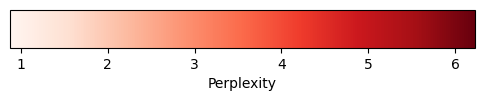

In [155]:
display_colored_sentences(filtered_tokens_p3_spk0, filtered_ppl_p3_spk0, tokenizer)

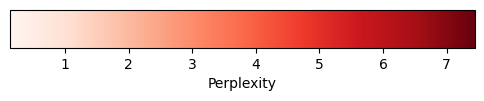

In [156]:
display_colored_sentences(filtered_tokens_p2_spk0, filtered_ppl_p2_spk0, tokenizer)

### Annotations

In [157]:
annotation_file = f"/u/sebono/conversational_dominance/data/processed/triadic-pilot/annotation_files/childs-joint-engagement-with-parent/aggregated_annotation_files.csv"

In [158]:
annotations = pd.read_csv(annotation_file)
annotations_dataset = annotations[annotations['uniq_vid_clip'].str.startswith(file_name)]
annotations_dataset.head()

,Unnamed: 0,Label-Name,NAN,Start-Timestamp,Start-Timestamp(sec),End-Timestamp,End-Timestamp(sec),Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
7758,0,p07-child (joint-engagement-wt-parent),NaN,00:00:00.000,0.0,00:00:05.000,5.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-0.0,NaN,NaN
7759,1,p07-child (joint-engagement-wt-parent),NaN,00:00:05.000,5.0,00:00:10.000,10.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-5.0,NaN,NaN
7760,2,p07-child (joint-engagement-wt-parent),NaN,00:00:10.000,10.0,00:00:15.000,15.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-10.0,NaN,NaN
7761,3,p07-child (joint-engagement-wt-parent),NaN,00:00:15.000,15.0,00:00:20.000,20.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-15.0,NaN,NaN
7762,4,p07-child (joint-engagement-wt-parent),NaN,00:00:20.000,20.0,00:00:25.000,25.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-20.0,NaN,NaN


In [159]:
conversation_dataset_file = f'/u/sebono/conversational_dominance/data/external/triadic-pilot/{file_name}_REV.csv'
conversation_dataset = pd.read_csv(conversation_dataset_file)
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content
0,0,00:00:00,2021-06-09 18:56:46,Robot,Hello.
1,1,00:00:00,2021-06-09 18:56:46,Child,(laughs). Hello.
2,2,00:00:00,2021-06-09 18:56:46,Parent,Hello.
3,3,00:00:04,2021-06-09 18:56:50,Robot,"I am now on story time mode, my camera will no..."
4,4,00:00:13,2021-06-09 18:56:59,Parent,Let's get started.
...,...,...,...,...,...
380,380,00:29:26,2021-06-09 19:26:12,Robot,I had so much fun. I-
381,381,00:29:28,2021-06-09 19:26:14,Child,[crosstalk 00:29:28]-
382,382,00:29:28,2021-06-09 19:26:14,Robot,Will now stop recording to respect your privac...
383,383,00:29:44,2021-06-09 19:26:30,Child,[crosstalk 00:29:44]-


In [160]:
assert len(matches) == len(conversation_dataset['content'])

In [161]:
conversation_dataset["tokens"] = [token.detach().numpy() for token in filtered_tokens_p1]
conversation_dataset[conversation_dataset['speaker']=='Child']

,Unnamed: 0,timestamp,real_time,speaker,content,tokens
1,1,00:00:00,2021-06-09 18:56:46,Child,(laughs). Hello.,"[764, 18435, 13, 220]"
8,8,00:00:25,2021-06-09 18:57:11,Child,[inaudible 00:00:25].,"[764, 220]"
10,10,00:01:06,2021-06-09 18:57:52,Child,Three Little Pig.,"[7683, 7703, 23097, 13, 220]"
12,12,00:01:09,2021-06-09 18:57:55,Child,You.,"[921, 13, 220]"
14,14,00:01:28,2021-06-09 18:58:14,Child,A mama pig.,"[317, 285, 1689, 12967, 13, 220]"
...,...,...,...,...,...,...
370,370,00:28:54,2021-06-09 19:25:40,Child,I'll-,"[314, 1183, 12, 220]"
372,372,00:28:57,2021-06-09 19:25:43,Child,I'll-,"[314, 1183, 12, 220]"
374,374,00:28:57,2021-06-09 19:25:43,Child,The-,"[383, 12, 220]"
381,381,00:29:28,2021-06-09 19:26:14,Child,[crosstalk 00:29:28]-,"[532, 220]"


In [162]:
import pandas as pd

#df = conversation_dataset[conversation_dataset['speaker']=='Child'].copy()
df = conversation_dataset.copy()
df["start_time"] = pd.to_timedelta(df["timestamp"]).dt.total_seconds()
df["end_time"] = df["start_time"].shift(-1)
df.loc[df.index[-1], "end_time"] = df["start_time"].iloc[-1] + 1
df = df[["start_time", "end_time", "speaker", "content", "tokens"]]

In [163]:
import numpy as np
import pandas as pd
import torch
from collections import defaultdict

def assign_words_to_bins(df, bin_size=5.0):
    """
    Assigns tokens to time bins based on uniform spread over the utterance duration.
    Includes utterances with 0 duration. Ensures all bins from time 0 to max stop are represented.

    Args:
        df (pd.DataFrame): DataFrame with columns ['start_time', 'end_time', 'tokens']
        bin_size (float): Size of each time bin in seconds

    Returns:
        pd.DataFrame: each row is a bin with its start/end time, decoded words, token indices, and token count
    """
    bin_tok = defaultdict(list)
    bin_ppl = defaultdict(list)
    global_token_idx = 0

    for _, row in df.iterrows():
        start = row["start_time"]
        stop = row["end_time"]
        tokens = row["tokens"]

        if pd.isna(start) or pd.isna(stop) or tokens is None or len(tokens) == 0:
            continue

        duration = stop - start
        if duration < 0:
            continue

        # Handle 0-duration: treat as a very short utterance
        if duration == 0:
            duration = 1e-6

        # Token timing interpolation
        tok_times = np.linspace(start, stop, len(tokens) + 1)

        for i, token in enumerate(tokens):
            tok_start = tok_times[i]
            tok_end = tok_times[i + 1]

            bin_start_idx = int(np.floor(tok_start / bin_size))
            bin_end_idx = int(np.floor((tok_end - 1e-6) / bin_size))  # avoid border collision

            for b in range(bin_start_idx, bin_end_idx + 1):
                bin_tok[b].append(token)
                bin_ppl[b].append(global_token_idx + i)

        global_token_idx += len(tokens)

    # Build output DataFrame
    max_bin = int(np.ceil(df["end_time"].max() / bin_size))
    all_bins = list(range(max_bin + 1))

    bins_df = pd.DataFrame([
        {
            "time_bin": b,
            "start_time": b * bin_size,
            "end_time": (b + 1) * bin_size,
            "words": tokenizer.decode(torch.tensor(bin_tok[b]), skip_special_tokens=True),
            "ppl": bin_ppl[b],
            "tokens": torch.tensor(bin_tok[b]),
            "n_tok": len(bin_tok[b])
        }
        for b in all_bins
    ])

    return bins_df

In [164]:
bins_df = assign_words_to_bins(df, bin_size=5.0)

In [165]:
bins_df

,time_bin,start_time,end_time,words,ppl,tokens,n_tok
0,0,0.0,5.0,Hello. I am now,"[7, 8, 9, 10, 11, 12]","[tensor(18435), tensor(13), tensor(220), tenso...",6
1,1,5.0,10.0,"on story time mode, my camera will now turn o...","[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 2...","[tensor(319), tensor(1621), tensor(640), tenso...",15
2,2,10.0,15.0,video recording. Let's get started. Let's ge...,"[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3...","[tensor(2008), tensor(8296), tensor(13), tenso...",20
3,3,15.0,20.0,storybooks together. Yes. If you haven't al...,"[48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 5...","[tensor(1621), tensor(12106), tensor(1978), te...",16
4,4,20.0,25.0,the Jibo Story Time app. Let's go ahead and s...,"[63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 7...","[tensor(262), tensor(449), tensor(26762), tens...",20
...,...,...,...,...,...,...,...
353,353,1765.0,1770.0,Okay. I had so much fun. I- - Will now sto...,"[5408, 5409, 5410, 5411, 5412, 5413, 5414, 541...","[tensor(16805), tensor(13), tensor(220), tenso...",21
354,354,1770.0,1775.0,your privacy. Please give me a few minutes to...,"[5428, 5429, 5430, 5431, 5432, 5433, 5434, 543...","[tensor(534), tensor(6782), tensor(13), tensor...",16
355,355,1775.0,1780.0,"back to leisure mode shortly. Oh, and please ...","[5443, 5444, 5445, 5446, 5447, 5448, 5449, 545...","[tensor(736), tensor(284), tensor(24638), tens...",17
356,356,1780.0,1785.0,up for the next session. Thank you. Bye bye. ...,"[5459, 5460, 5461, 5462, 5463, 5464, 5465, 546...","[tensor(510), tensor(329), tensor(262), tensor...",17


In [166]:
combined_df = pd.concat([bins_df.reset_index(drop=True), annotations_dataset.iloc[:bins_df.shape[0]].reset_index(drop=True)], axis=1)
combined_df.iloc[0:]

,time_bin,start_time,end_time,words,ppl,tokens,n_tok,Unnamed: 0,Label-Name,NAN,...,Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
0,0,0.0,5.0,Hello. I am now,"[7, 8, 9, 10, 11, 12]","[tensor(18435), tensor(13), tensor(220), tenso...",6,0.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-0.0,NaN,NaN
1,1,5.0,10.0,"on story time mode, my camera will now turn o...","[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 2...","[tensor(319), tensor(1621), tensor(640), tenso...",15,1.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-5.0,NaN,NaN
2,2,10.0,15.0,video recording. Let's get started. Let's ge...,"[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3...","[tensor(2008), tensor(8296), tensor(13), tenso...",20,2.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-10.0,NaN,NaN
3,3,15.0,20.0,storybooks together. Yes. If you haven't al...,"[48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 5...","[tensor(1621), tensor(12106), tensor(1978), te...",16,3.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-15.0,NaN,NaN
4,4,20.0,25.0,the Jibo Story Time app. Let's go ahead and s...,"[63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 7...","[tensor(262), tensor(449), tensor(26762), tens...",20,4.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-20.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,353,1765.0,1770.0,Okay. I had so much fun. I- - Will now sto...,"[5408, 5409, 5410, 5411, 5412, 5413, 5414, 541...","[tensor(16805), tensor(13), tensor(220), tenso...",21,353.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-1765.0,NaN,NaN
354,354,1770.0,1775.0,your privacy. Please give me a few minutes to...,"[5428, 5429, 5430, 5431, 5432, 5433, 5434, 543...","[tensor(534), tensor(6782), tensor(13), tensor...",16,354.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-1770.0,NaN,NaN
355,355,1775.0,1780.0,"back to leisure mode shortly. Oh, and please ...","[5443, 5444, 5445, 5446, 5447, 5448, 5449, 545...","[tensor(736), tensor(284), tensor(24638), tens...",17,355.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-1775.0,NaN,NaN
356,356,1780.0,1785.0,up for the next session. Thank you. Bye bye. ...,"[5459, 5460, 5461, 5462, 5463, 5464, 5465, 546...","[tensor(510), tensor(329), tensor(262), tensor...",17,356.0,p07-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p07_s03_zoom_trimmed.txt,p07_s03_zoom_trimmed.txt-1780.0,NaN,NaN


In [167]:
import pandas as pd

def expand_multiple_ppl_by_token(bin_df, ppl_dict, annotation_cols=None):
    """
    Expands a bin-level DataFrame into token-level rows, adding multiple PPL values per token.

    Args:
        bin_df (pd.DataFrame): must contain 'ppl' as a list of token indices.
        ppl_dict (dict): dictionary of {name: List[float]}, e.g. {'ppl1': [...], 'ppl2': [...]}
        annotation_cols (List[str]): optional list of annotation columns to repeat per token.

    Returns:
        pd.DataFrame: one row per token with multiple ppl values and repeated annotations.
    """
    # Validate that all ppl lists have the same length
    lengths = [len(v) for v in ppl_dict.values()]
    if not all(l == lengths[0] for l in lengths):
        raise ValueError("All PPL arrays must have the same length.")

    records = []

    for _, row in bin_df.iterrows():
        token_ids = row["ppl"]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        for tok_id in token_ids:
            if tok_id >= lengths[0]:
                continue  # skip out-of-bounds

            record = {"token_id": tok_id}
            for name, ppl_values in ppl_dict.items():
                record[name] = ppl_values[tok_id]

            if annotation_cols:
                for col in annotation_cols:
                    record[col] = row.get(col, None)

            records.append(record)

    return pd.DataFrame(records)

In [168]:
cols = ['Rating_x', 'Rating_y','start_time','end_time','words']
ppl_dict = {'p1': all_data_filtered["p1"], 'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_filtered_expanded = expand_multiple_ppl_by_token(combined_df, ppl_dict, annotation_cols=cols)

In [169]:
from sklearn.decomposition import PCA
all_data_filtered_expanded.ffill(inplace=True)
X = np.column_stack((all_data_filtered_expanded["p2"],all_data_filtered_expanded["p3"]))

In [170]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

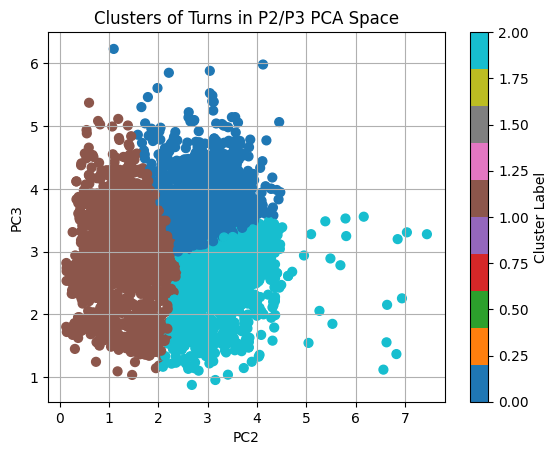

In [171]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [172]:
all_data_filtered_expanded[:50]

,token_id,p1,p2,p3,Rating_x,Rating_y,start_time,end_time,words
0,7,1.225772,0.309451,1.735585,NaN,NaN,0.0,5.0,Hello. I am now
1,8,0.236080,0.298970,1.859345,NaN,NaN,0.0,5.0,Hello. I am now
2,9,0.370205,0.307874,1.448593,NaN,NaN,0.0,5.0,Hello. I am now
3,10,3.793251,0.649723,2.404466,NaN,NaN,0.0,5.0,Hello. I am now
4,11,2.472806,0.910163,1.826698,NaN,NaN,0.0,5.0,Hello. I am now
5,12,4.536381,1.363441,2.014303,NaN,NaN,0.0,5.0,Hello. I am now
6,13,3.719758,1.625254,2.035613,NaN,NaN,5.0,10.0,"on story time mode, my camera will now turn o..."
7,14,11.917119,2.654439,2.043081,NaN,NaN,5.0,10.0,"on story time mode, my camera will now turn o..."
8,15,5.989134,2.957593,1.538419,NaN,NaN,5.0,10.0,"on story time mode, my camera will now turn o..."
9,16,7.777567,3.359257,1.584518,NaN,NaN,5.0,10.0,"on story time mode, my camera will now turn o..."


In [173]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0][:10]
    print(all_data_filtered_expanded.iloc[indices]['words'].to_numpy())


--- Cluster 0 ---
[' on story time mode, my camera will now turn on and start audio and'
 ' on story time mode, my camera will now turn on and start audio and'
 " the Jibo Story Time app. Let's go ahead and select a book on the app. "
 " the Jibo Story Time app. Let's go ahead and select a book on the app. "
 ' Loading. Oh, which one would you like? Geraldine'
 ' Loading. Oh, which one would you like? Geraldine'
 ' Loading. Oh, which one would you like? Geraldine'
 ', The Little Red Hen, The Little Red Hen, The Three'
 ', The Little Red Hen, The Little Red Hen, The Three'
 ', The Little Red Hen, The Little Red Hen, The Three']

--- Cluster 1 ---
[' Hello.  I am now' ' Hello.  I am now' ' Hello.  I am now'
 ' Hello.  I am now' ' Hello.  I am now' ' Hello.  I am now'
 ' on story time mode, my camera will now turn on and start audio and'
 " video recording. Let's get started.  Let's get started.  Now we will be reading"
 " video recording. Let's get started.  Let's get started.  Now we w

In [174]:
# AFTER
col_1 = ["p2","p3","p1"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_filtered_expanded)

In [175]:
fig_corr

In [176]:
def average_ppl_per_turn(df, ppl_dict, idx_col='ppl', annotation_cols=None):
    """
    For each row in df, average values from ppl_dict at indices listed in df[idx_col].

    Args:
        df (pd.DataFrame): DataFrame with a column of token indices (e.g., 'ppl').
        ppl_dict (dict): Dictionary with name -> list of PPL values.
        idx_col (str): Column in df with list of indices per turn.
        annotation_cols (List[str]): Optional columns to carry forward.

    Returns:
        pd.DataFrame: Averaged PPL values per turn, optionally with annotations.
    """
    import numpy as np
    import pandas as pd

    records = []
    for _, row in df.iterrows():
        token_ids = row[idx_col]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        record = {}
        for name, ppl_values in ppl_dict.items():
            selected = [ppl_values[i] for i in token_ids if i < len(ppl_values)]
            record[f'{name}_avg'] = np.mean(selected) if selected else None
            record['tokens'] = token_ids
            record['tok_len'] = len(token_ids)

        if annotation_cols:
            for col in annotation_cols:
                record[col] = row.get(col, None)

        records.append(record)

    return pd.DataFrame(records)

In [177]:
all_data_filtered

,p1,p2,p3
0,6.813503,6.008404,2.579680
1,3.093827,5.522642,2.613021
2,5.891013,5.575266,2.663951
3,7.410665,3.537606,0.891203
4,6.145959,3.910229,1.624395
...,...,...,...
5500,2.676596,3.238294,1.605971
5501,2.669240,0.963728,1.721245
5502,0.320889,0.814250,1.455163
5503,4.905847,0.858934,3.008482


In [178]:
cols = ['Rating_x', 'Rating_y','words','start_time','end_time', 'tokens']
ppl_dict = {'p1': all_data_filtered["p1"], 'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_filtered_expanded = average_ppl_per_turn(combined_df, ppl_dict, annotation_cols=cols)

In [179]:
all_data_filtered_expanded

,p1_avg,tokens,tok_len,p2_avg,p3_avg,Rating_x,Rating_y,words,start_time,end_time
0,2.105749,"[tensor(18435), tensor(13), tensor(220), tenso...",6,0.639937,1.881499,NaN,NaN,Hello. I am now,0.0,5.0
1,5.253782,"[tensor(319), tensor(1621), tensor(640), tenso...",15,3.333106,2.520593,NaN,NaN,"on story time mode, my camera will now turn o...",5.0,10.0
2,2.340371,"[tensor(2008), tensor(8296), tensor(13), tenso...",20,2.326017,2.214269,NaN,NaN,video recording. Let's get started. Let's ge...,10.0,15.0
3,3.286192,"[tensor(1621), tensor(12106), tensor(1978), te...",16,1.758196,2.511207,NaN,NaN,storybooks together. Yes. If you haven't al...,15.0,20.0
4,3.530532,"[tensor(262), tensor(449), tensor(26762), tens...",20,3.144166,2.692389,NaN,NaN,the Jibo Story Time app. Let's go ahead and s...,20.0,25.0
...,...,...,...,...,...,...,...,...,...,...
352,4.247523,"[tensor(13), tensor(220), tensor(575), tensor(...",15,3.718470,3.446568,NaN,NaN,. Yay. That's it for today's session.,1760.0,1765.0
353,2.546338,"[tensor(16805), tensor(13), tensor(220), tenso...",21,1.594650,2.650025,NaN,NaN,Okay. I had so much fun. I- - Will now sto...,1765.0,1770.0
354,2.559129,"[tensor(534), tensor(6782), tensor(13), tensor...",16,1.197707,2.963570,NaN,NaN,your privacy. Please give me a few minutes to...,1770.0,1775.0
355,3.883245,"[tensor(736), tensor(284), tensor(24638), tens...",17,2.580244,2.889763,NaN,NaN,"back to leisure mode shortly. Oh, and please ...",1775.0,1780.0


In [180]:
sum(all_data_filtered_expanded['Rating_x']==1), sum(all_data_filtered_expanded['Rating_x']==0), sum(all_data_filtered_expanded['Rating_x']==2), sum(all_data_filtered_expanded['Rating_x']==-2), sum(all_data_filtered_expanded['Rating_x']==-1)

(185, 129, 0, 0, 5)

In [181]:
from utils import correlation_heatmap

In [182]:
# AFTER
col_1 = ["p1_avg","p2_avg","p3_avg"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_filtered_expanded)

In [183]:
fig_r

In [184]:
fig_corr

In [185]:
fig_p

In [186]:
# p2 --> high ppl, less predictable utterace --> more topical dominance
# A: hi my name is Serena.| B: I don't care, get back to work! --> very unliklely utterance, really high ppl, B: is dominant
# p3 --> high ppl, less likely to be interrupted --> more interactional dominance
# A: hi my name is Serena.| B: I don't care, [:A] --> very unliklely interruption, really high ppl, B: is dominant
# follows that dominance should be directly correlated w. perplexity.
# engagement tho... it depends. If the roles are child/parent, then an imbalanced conversation is to be expected.

# interruptions are inversely correlated to engagement?
# topical dominance is directly correlated to engagement?
# Is this general, likely not!

In [187]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Drop NaNs
all_data_filtered_expanded.dropna(inplace=True)

# Features
X = all_data_filtered_expanded[['p2_avg', 'p3_avg']]

# Binarize target
y = (all_data_filtered_expanded['Rating_x'] >= 1).astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.625
Confusion Matrix:
 [[23 12]
 [12 17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.66      0.66        35
           1       0.59      0.59      0.59        29

    accuracy                           0.62        64
   macro avg       0.62      0.62      0.62        64
weighted avg       0.62      0.62      0.62        64



In [188]:
import pandas as pd

feature_names = ['p2_avg', 'p3_avg']
coeffs = model.coef_[0]

for name, val in zip(feature_names, coeffs):
    print(f"{name}: {val:.4f}")


p2_avg: -0.3028
p3_avg: -1.0808


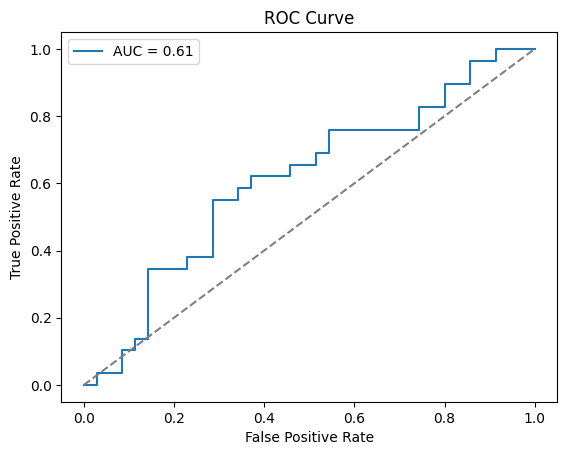

In [189]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

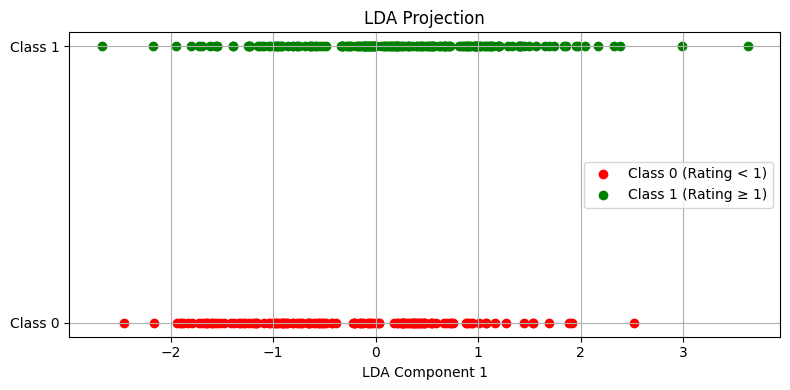

In [190]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt

# Use the same X and y from before
lda = LDA(n_components=1)  # Only 1 component for binary classification
X_lda = lda.fit_transform(X, y)

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(X_lda[y==0], [0]*sum(y==0), c='red', label='Class 0 (Rating < 1)')
plt.scatter(X_lda[y==1], [1]*sum(y==1), c='green', label='Class 1 (Rating ≥ 1)')
plt.title("LDA Projection")
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel("LDA Component 1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [191]:
X

,p2_avg,p3_avg
14,2.579759,2.782709
15,3.102184,3.177362
16,3.109079,3.156510
17,2.201097,2.793722
18,1.634891,3.418257
...,...,...
347,2.074712,2.872209
348,3.011076,3.343822
349,3.128512,3.183015
350,3.236625,2.918904


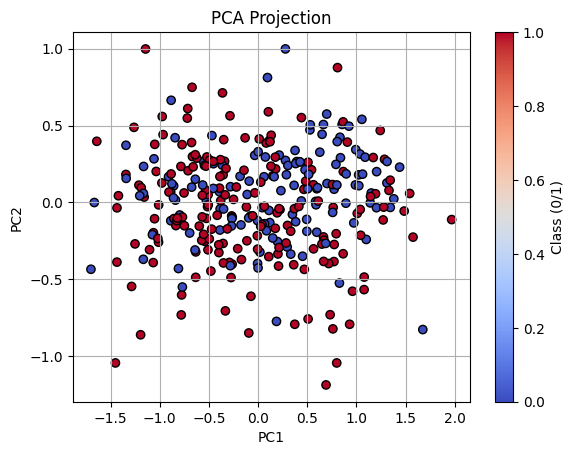

In [192]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X[['p2_avg','p3_avg']])

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.colorbar(label='Class (0/1)')
plt.show()


In [93]:
all_data_filtered_expanded

,p1_avg,tokens,tok_len,p2_avg,p3_avg,Rating_x,Rating_y,words,start_time,end_time
14,2.342122,"[tensor(13), tensor(220), tensor(29946), tenso...",13,3.743164,4.700881,0.0,0.0,. ibo. Once upon a time an old sow sent her,70.0,75.0
15,1.772728,"[tensor(1077), tensor(2380), tensor(2697), ten...",19,2.766244,4.864586,0.0,0.0,her three little pigs out into the world to s...,75.0,80.0
16,2.048869,"[tensor(3350), tensor(1359), tensor(1364), ten...",19,2.471200,4.889285,0.0,0.0,"write,"" she said, ""And remember that I love y...",80.0,85.0
17,1.235757,"[tensor(58565), tensor(374), tensor(30), tenso...",19,2.740753,4.663320,1.0,1.0,"sow is? What do you think it is? mama pig., ...",85.0,90.0
18,1.941454,"[tensor(264), tensor(57264), tensor(24623), te...",17,2.491105,5.085548,0.0,0.0,a mama pig. The first little pig met a man wi...,90.0,95.0
...,...,...,...,...,...,...,...,...,...,...
347,2.527068,"[tensor(13), tensor(5112), tensor(12), tensor(...",38,3.627217,4.269668,1.0,1.0,". Then- 'll- k and hiss, just like this. Did y...",1735.0,1740.0
348,1.323806,"[tensor(12), tensor(220)]",2,3.122234,4.468849,0.0,0.0,-,1740.0,1745.0
349,0.489001,[tensor(220)],1,3.027171,4.269996,1.0,1.0,,1745.0,1750.0
350,2.076259,"[tensor(220), tensor(842), tensor(13)]",3,3.075406,4.461111,0.0,0.0,end.,1750.0,1755.0


In [94]:
repeated_p2_list = sum([[p2] * l for p2, l in zip(all_data_filtered_expanded['p2_avg'], all_data_filtered_expanded['tok_len'])], [])

In [95]:
repeated_p3_list = sum([[p3] * l for p3, l in zip(all_data_filtered_expanded['p3_avg'], all_data_filtered_expanded['tok_len'])], [])

In [96]:
assert all_data_filtered_expanded["tok_len"].sum() == len(repeated_p2_list)

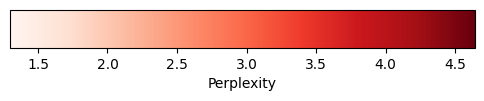

In [97]:
display_colored_sentences(list(all_data_filtered_expanded['tokens']), repeated_p2_list, tokenizer)

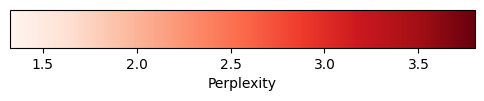

In [266]:
display_colored_sentences(list(all_data_filtered_expanded['tokens']), repeated_p3_list, tokenizer)

### Clusters

In [ ]:
all_data_filtered_expanded["p2_avg"]

In [ ]:
from sklearn.decomposition import PCA
all_data_filtered.ffill(inplace=True)
X = np.column_stack((all_data_filtered_expanded["p2_avg"],all_data_filtered_expanded["p3_avg"]))

In [ ]:
all_data_filtered_expanded

In [ ]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [ ]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0][:10]
    print(all_data_filtered_expanded.iloc[indices]['words'].to_numpy())


### Finding Signal

In [ ]:
from utils import compute_dominance_per_spk, compute_significance

In [ ]:
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data_filtered["p2"], filtered_tokens_p1, matches, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data_filtered["p3"], filtered_tokens_p1, matches, tokenizer)

In [ ]:
all_data_filtered_expanded

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

cols = ['Rating_x','Rating_y']
# Perform correlation
stat, pval = spearmanr(all_data_filtered_expanded['p2_avg'], all_data_filtered_expanded[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


In [ ]:
X = all_data_filtered_expanded[cols].fillna(0)
y = all_data_filtered_expanded['p3_avg']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)

In [ ]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(rf, X, ['Rating_y'])
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
# Features and target
all_data_filtered_expanded.dropna(inplace=True)
X = all_data_filtered_expanded[cols]
y = all_data_filtered_expanded["p3_avg"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
!pip install shap

In [ ]:
import shap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)